<a href="https://colab.research.google.com/github/dilsh9810/IT3437_Assignment02/blob/master/IT5437_Assignment02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Q1**. **Line Fitting**

**a**) **Total** **Least** **Squares** **(TLS)**

The Orthoginal distance in Total Least Square for the first line in the dataset(x1,y1) is calculated based on the orthogonal distances of the points from the fitted line. This process involves the application of Singular Value Decomposition after centering the data.


In [ ]:
import numpy as np
import pandas as pd

# 1. Load the data
df = pd.read_csv('/content/lines.csv')
# Clean column names by removing leading '#' and stripping whitespace
df.columns = df.columns.str.replace('# ', '', regex=False).str.strip()
x = df['x1'].values
y = df['y1'].values

# 2. Center the data
x_mean, y_mean = np.mean(x), np.mean(y)
pts_centered = np.vstack([x - x_mean, y - y_mean]).T

# 3. Perform SVD
# The last row of Vh (or last column of V) corresponds to
# the smallest singular value and represents the line normal.
_, _, vh = np.linalg.svd(pts_centered)
a, b = vh[1, :]

# 4. Calculate the intercept
c = -(a * x_mean + b * y_mean)

print(f"Resulting Line: {a:.4f}x + {b:.4f}y + {c:.4f} = 0")

Resulting Line: 0.7736x + -0.6337y + -3.7942 = 0


b). **Interative** **RANSAC**

In [1]:
import numpy as np

data = np.genfromtxt("/content/sample_data/lines.csv", delimiter=",", skip_header=1)

x_value = data[:, :3]
y_value = data[:, 3:]

x_all = x_value.flatten()
y_all = y_value.flatten()

points = np.vstack([x_all, y_all]).T

def get_line_params(p1, p2):
    v = p2 - p1
    n = np.array([-v[1], v[0]])
    norm = np.linalg.norm(n)
    if norm == 0: return None
    n = n / norm
    d = -np.dot(n, p1)
    return n[0], n[1], d

def ransac_line(pts, threshold=0.1, iterations=1000):
    best_params = None
    best_inliers = []

    for _ in range(iterations):
        idx = np.random.choice(len(pts), 2, replace=False)
        p1, p2 = pts[idx]
        params = get_line_params(p1, p2)
        if params is None: continue

        a, b, d = params
        dist = np.abs(a * pts[:, 0] + b * pts[:, 1] + d)
        inliers = np.where(dist < threshold)[0]

        if len(inliers) > len(best_inliers):
           best_inliers = inliers
           best_params = params

    return best_params, best_inliers

remaining_points = points.copy()
results = []

for i in range(3):
    params, inlier_indices = ransac_line(remaining_points)
    if params is not None:
        results.append(params)
        remaining_points = np.delete(remaining_points, inlier_indices, axis=0)
        print(f"Line {i+1} Parameters: {params[0]:.4f}x + {params[1]:.4f}y + {params[2]:.4f} = 0")

Line 1 Parameters: 0.4336x + 0.9011y + -2.1038 = 0
Line 2 Parameters: 0.7259x + -0.6878y + 0.6053 = 0
Line 3 Parameters: -0.4337x + -0.9010y + 1.6621 = 0


**Q2 Sizes of the earrings**

**Step** **1**: **Calculate** **the** **Image** **Distance**

1/v = 1/8 -  1/u = 1/720 => 1/v = (90 - 1) / 720 = 89 / 720

v = 8.0899mm



**Step** 2: **Determine** **Magnification**

   M = v / u

  = 8.0899 / 720

  = 0.011236

**Step** 3 **Measure** **the** **Earring** **in** **Pixels**

**Real width = 375 x 0.0022 / 0.011236**

= 73.43mm

**Real Height = 399 * 0.0022 / 0.0011236**

= 78.12mm

In [3]:
import numpy as np

# --- Step 0: Input Parameters ---
# Focal length of the lens (f) in mm
focal_length = 8.0
# Distance of the object from the lens (u) in mm
object_distance = 720.0
# Pixel dimensions measured in the image
width_px = 375
height_px = 399
# Physical size of one pixel on the sensor in mm
pixel_size_mm = 0.0022

# --- Step 1: Calculate the Image Distance (v) ---
# Using the thin lens formula: 1/f = 1/u + 1/v => 1/v = 1/f - 1/u
inv_v = (1 / focal_length) - (1 / object_distance)
image_distance = 1 / inv_v

# --- Step 2: Determine Magnification (M) ---
# Magnification is the ratio of image distance to object distance
magnification = image_distance / object_distance

# --- Step 3: Calculate Real-World Dimensions ---
# First, convert pixel measurements to physical sensor size (mm)
width_on_sensor = width_px * pixel_size_mm
height_on_sensor = height_px * pixel_size_mm

# Then, divide by magnification to find the actual size of the earring
real_width_mm = width_on_sensor / magnification
real_height_mm = height_on_sensor / magnification

# --- Output Results ---
print(f"--- Earring Measurement Results ---")
print(f"Image Distance (v): {image_distance:.4f} mm")
print(f"Magnification (M):  {magnification:.6f}")
print(f"Real-World Width:    {real_width_mm:.2f} mm")
print(f"Real-World Height:   {real_height_mm:.2f} mm")

--- Earring Measurement Results ---
Image Distance (v): 8.0899 mm
Magnification (M):  0.011236
Real-World Width:    73.43 mm
Real-World Height:   78.12 mm


**Q3**). **Select** **Points**


SIFT Resulting Warped Image:


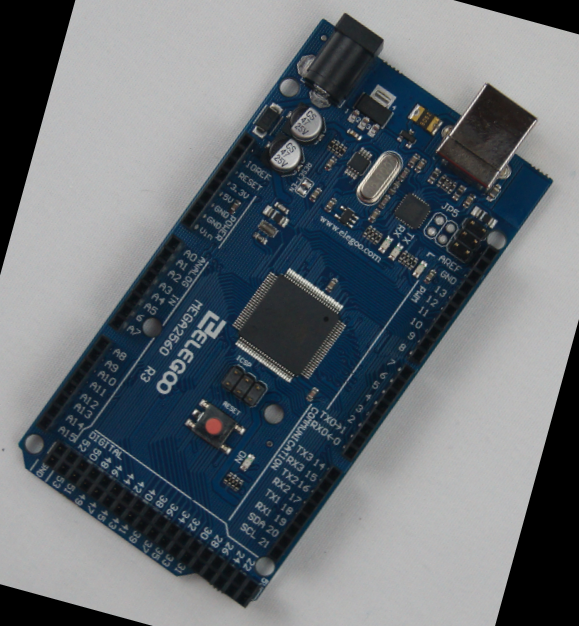

Difference Image:


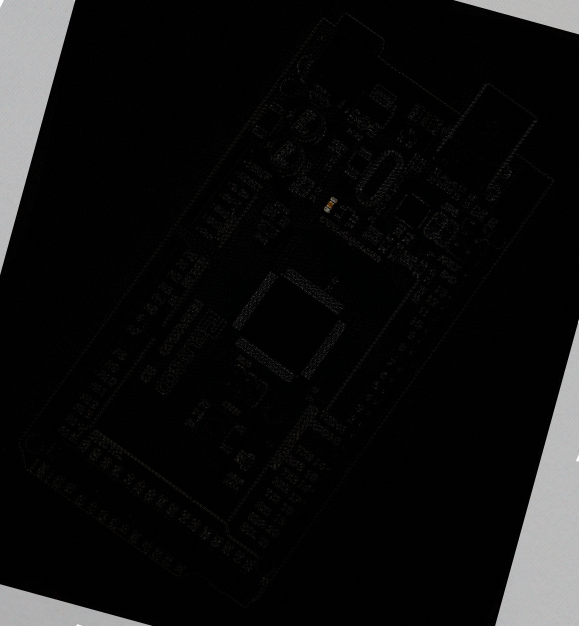

In [2]:
import cv2 as cv
import numpy as np
from google.colab.patches import cv2_imshow

# NOTE: Interactive mouse clicking (cv.setMouseCallback) does not work in Colab.
# You would typically need to use a JS snippet or define manual points for Colab.
# I am updating the code to use cv2_imshow to prevent crashing.

im1 = cv.imread('/content/sample_data/c1.jpg', cv.IMREAD_REDUCED_COLOR_4)
im2 = cv.imread('/content/sample_data/c2.jpg', cv.IMREAD_REDUCED_COLOR_4)

if im1 is None or im2 is None:
    print("Error: Could not load images. Check the file paths.")
else:
    h, w, _ = im2.shape

    # SIFT/ORB Keypoints and Matching (Automated approach is safer in Colab)
    sift = cv.SIFT_create()
    kp1, des1 = sift.detectAndCompute(im1, None)
    kp2, des2 = sift.detectAndCompute(im2, None)

    bf = cv.BFMatcher()
    matches = bf.knnMatch(des1, des2, k=2)

    good_matches = [m for m, n in matches if m.distance < 0.75 * n.distance]

    if len(good_matches) > 4:
        src_pts = np.float32([kp1[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
        dst_pts = np.float32([kp2[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)

        H_auto, mask = cv.findHomography(src_pts, dst_pts, cv.RANSAC, 5.0)
        im1_warped_auto = cv.warpPerspective(im1, H_auto, (w, h))
        difference_auto = cv.absdiff(im2, im1_warped_auto)

        print("SIFT Resulting Warped Image:")
        cv2_imshow(im1_warped_auto)
        print("Difference Image:")
        cv2_imshow(difference_auto)
    else:
        print("Not enough matches found.")